# 🌾 Machine Learning Hands-On Workshop

**Organized by Scenius Hub — ahead of IndabaX South Sudan 2026**

Welcome! This notebook is your hands-on introduction to Machine Learning. By the end of today's session you will have:

- Learned the core vocabulary and workflow of Machine Learning
- Explored, cleaned, and prepared a real-world-style dataset
- Trained and evaluated both a **regression** model and a **classification** model
- Worked through guided exercises to practice the workflow yourself

This workshop is deliberately hands-on and uses a **South Sudan agriculture / food security dataset**, so the skills you practice today will feed directly into the **IndabaX South Sudan 2026 hackathon** (agriculture & food security forecasting).

### How to use this notebook
1. This notebook is designed for **Google Colab** — you're in the right place if you opened it there.
2. Run cells **from top to bottom**, one at a time, using `Shift + Enter`. Don't skip ahead — later cells depend on earlier ones.
3. Cells marked **🧪 Try it yourself** are for you to edit and experiment with. There is no single "correct" answer — the goal is to practice.
4. If you get an error, re-read the cell above it first — most errors come from skipping a step.
5. Ask a facilitator any time you're stuck. That's what we're here for!

### Today's agenda
| Part | Topic |
|---|---|
| 0 | Setup |
| 1 | What is Machine Learning? |
| 2 | Our dataset: crop yield & food security in South Sudan |
| 3 | Exploring the data (EDA) |
| 4 | Cleaning & preparing the data |
| 5 | Splitting the data |
| 6 | Regression: predicting crop yield |
| 7 | Classification: predicting food security risk |
| 8 | 🧪 Hands-on challenge |
| 9 | Wrap-up & next steps |


## Part 0 — Setup

We'll use a standard Python data science stack:

- **pandas** — for working with tabular data
- **numpy** — for numerical operations
- **matplotlib** / **seaborn** — for plotting
- **scikit-learn** — for machine learning models

All of these come pre-installed on Google Colab, so the cell below should run instantly.


In [ ]:
# Install (safe no-op on Colab, where these are already present)
!pip install -q scikit-learn seaborn pandas numpy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, confusion_matrix, classification_report
)

# Reproducibility: fixing the random seed means everyone in the room
# gets the same numbers, which makes it easier to compare results.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Setup complete ✅")


Setup complete ✅


## Part 1 — What is Machine Learning?

**Machine Learning (ML)** is a way of teaching computers to find patterns in data and use those patterns to make predictions or decisions — instead of us writing explicit rules by hand.

### Two families of problems we'll see today

| | Question it answers | Example | Today's example |
|---|---|---|---|
| **Regression** | "How much / how many?" | Predict a house price | Predict **crop yield (kg/ha)** |
| **Classification** | "Which category?" | Is this email spam or not? | Predict **food security risk** (Low / Medium / High) |

Both are examples of **supervised learning**: we give the model past examples where we already know the answer (the *label*), and it learns the relationship between the inputs (*features*) and that answer.

### The typical ML workflow (what we'll do today, in order)

```
1. Define the problem   →  What are we trying to predict, and why?
2. Collect the data     →  Gather examples with known outcomes
3. Explore the data     →  Understand it: shape, ranges, gaps, patterns
4. Clean & prepare it   →  Handle missing values, encode categories, scale numbers
5. Split the data       →  Separate "training" examples from "test" examples
6. Train a model        →  Let the algorithm learn patterns from the training data
7. Evaluate the model   →  Check performance on the *unseen* test data
8. Iterate              →  Try new features / models, and improve
```

Every one of these steps matters — a great model trained on badly-prepared data will still make bad predictions. Let's work through all eight steps together.


## Part 2 — Our dataset: crop yield & food security in South Sudan

For this workshop we'll use a **simulated dataset** of smallholder farm plots across South Sudan. It's built to reflect realistic relationships (rainfall and fertilizer drive yield, drought drives food security risk, etc.), so the techniques you practice transfer directly to real agricultural data — including whatever dataset you'll work with at the hackathon.

Each row is one farm plot in one growing season, with these columns:

| Column | Meaning |
|---|---|
| `region` | State in South Sudan where the plot is located |
| `crop` | Crop grown (Sorghum, Maize, Groundnuts, Cassava) |
| `farm_size_ha` | Size of the farm plot, in hectares |
| `rainfall_mm` | Total rainfall during the growing season (mm) |
| `avg_temp_c` | Average temperature during the growing season (°C) |
| `fertilizer_kg_ha` | Fertilizer applied, in kg per hectare (many smallholders use none) |
| `soil_quality_index` | A 0–10 index of soil quality |
| `market_access_score` | A 0–10 index of how easily a household can reach markets/services |
| `yield_kg_ha` | **Target 1 (regression):** crop yield achieved, in kg per hectare |
| `food_security_risk` | **Target 2 (classification):** Low / Medium / High risk for the household this season |

Run the cell below to generate the dataset.


In [ ]:
def generate_dataset(n=900, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)

    regions = ["Central Equatoria", "Eastern Equatoria", "Western Equatoria",
               "Jonglei", "Unity", "Upper Nile", "Warrap", "Lakes",
               "Western Bahr el Ghazal", "Northern Bahr el Ghazal"]
    crops = ["Sorghum", "Maize", "Groundnuts", "Cassava"]
    # A rough base yield (kg/ha) each crop tends toward under average conditions
    crop_base_yield = {"Sorghum": 900, "Maize": 1300, "Groundnuts": 700, "Cassava": 4500}

    region = rng.choice(regions, size=n)
    crop = rng.choice(crops, size=n, p=[0.35, 0.30, 0.20, 0.15])
    farm_size_ha = np.round(rng.gamma(shape=2.0, scale=0.8, size=n) + 0.2, 2)

    # Rainfall varies by region (some regions are wetter than others) plus noise
    region_rain_mean = {r: rng.uniform(650, 1100) for r in regions}
    rainfall_mm = np.array([max(50, rng.normal(region_rain_mean[r], 150)) for r in region])

    avg_temp_c = np.round(rng.normal(29, 2.5, size=n), 1)
    fertilizer_kg_ha = np.round(np.clip(rng.exponential(scale=25, size=n), 0, 200), 1)
    soil_quality_index = np.round(np.clip(rng.normal(5.5, 1.8, size=n), 0, 10), 1)
    market_access_score = np.round(np.clip(rng.normal(5, 2.2, size=n), 0, 10), 1)

    base = np.array([crop_base_yield[c] for c in crop])

    # Yield responds positively to rainfall (up to a point), fertilizer, and soil
    # quality, and drops sharply in drought-like conditions (rainfall < 500mm).
    rainfall_effect = np.clip(rainfall_mm, 0, 1100) / 850
    drought_penalty = np.where(rainfall_mm < 500, (500 - rainfall_mm) / 500 * 0.6, 0)
    fert_effect = 1 + (fertilizer_kg_ha / 200) * 0.35
    soil_effect = 1 + (soil_quality_index - 5) * 0.05

    yield_kg_ha = base * rainfall_effect * fert_effect * soil_effect * (1 - drought_penalty)
    yield_kg_ha = yield_kg_ha * rng.normal(1.0, 0.12, size=n)  # random noise
    yield_kg_ha = np.round(np.clip(yield_kg_ha, 50, None), 1)

    # Food security risk: driven mainly by yield relative to the crop's baseline,
    # plus market access (better market access cushions a bad harvest a little).
    relative_yield = yield_kg_ha / base
    risk_score = (1 - relative_yield) * 10 - (market_access_score - 5) * 0.3
    risk_score += rng.normal(0, 0.8, size=n)

    # Use quantile-based cut points so all three risk classes have enough
    # examples to learn from and evaluate (a real survey would rarely be this
    # neatly balanced, but for a teaching dataset we want every class to be
    # learnable within a short workshop).
    q50, q80 = np.quantile(risk_score, [0.50, 0.80])
    food_security_risk = pd.cut(
        risk_score, bins=[-np.inf, q50, q80, np.inf], labels=["Low", "Medium", "High"]
    ).astype(str)

    df = pd.DataFrame({
        "region": region,
        "crop": crop,
        "farm_size_ha": farm_size_ha,
        "rainfall_mm": np.round(rainfall_mm, 1),
        "avg_temp_c": avg_temp_c,
        "fertilizer_kg_ha": fertilizer_kg_ha,
        "soil_quality_index": soil_quality_index,
        "market_access_score": market_access_score,
        "yield_kg_ha": yield_kg_ha,
        "food_security_risk": food_security_risk,
    })

    # Sprinkle in some realistic missing values, like a real field survey would have
    for col, frac in [("rainfall_mm", 0.04), ("soil_quality_index", 0.05), ("market_access_score", 0.03)]:
        missing_idx = rng.choice(df.index, size=int(len(df) * frac), replace=False)
        df.loc[missing_idx, col] = np.nan

    return df

df = generate_dataset()
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.tail(5)


Dataset shape: 900 rows, 10 columns


,region,crop,farm_size_ha,rainfall_mm,avg_temp_c,fertilizer_kg_ha,soil_quality_index,market_access_score,yield_kg_ha,food_security_risk
895,Warrap,Maize,1.95,582.3,27.1,8.1,3.3,4.1,917.1,High
896,Upper Nile,Maize,0.95,631.9,28.6,28.1,8.6,5.1,1177.8,Medium
897,Central Equatoria,Maize,0.99,893.2,33.7,25.5,8.3,5.5,1564.1,Low
898,Central Equatoria,Maize,0.68,890.8,32.5,64.0,7.1,3.3,1876.9,Low
899,Warrap,Sorghum,2.96,713.8,29.9,25.2,4.8,7.0,884.7,Medium


## Part 3 — Exploring the data (EDA)

Before touching any model, we always look at the data first. We want to know:

- What types of columns do we have?
- Are there missing values?
- What do the distributions look like? Any outliers?
- Are there visible relationships between features and our targets?

This step is called **Exploratory Data Analysis (EDA)**, and skilled practitioners often spend more time here than on modeling itself.


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   region               900 non-null    object 
 1   crop                 900 non-null    object 
 2   farm_size_ha         900 non-null    float64
 3   rainfall_mm          864 non-null    float64
 4   avg_temp_c           900 non-null    float64
 5   fertilizer_kg_ha     900 non-null    float64
 6   soil_quality_index   855 non-null    float64
 7   market_access_score  873 non-null    float64
 8   yield_kg_ha          900 non-null    float64
 9   food_security_risk   900 non-null    object 
dtypes: float64(7), object(3)
memory usage: 70.4+ KB


In [ ]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
region,900,10,Eastern Equatoria,105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
crop,900,4,Sorghum,318,NaN,NaN,NaN,NaN,NaN,NaN,NaN
farm_size_ha,900.0,NaN,NaN,NaN,1.849167,1.189743,0.22,0.9875,1.61,2.39,7.85
rainfall_mm,864.0,NaN,NaN,NaN,835.095023,191.577648,317.0,702.775,826.55,970.25,1387.3
avg_temp_c,900.0,NaN,NaN,NaN,28.951333,2.514414,21.1,27.3,29.0,30.5,37.6
fertilizer_kg_ha,900.0,NaN,NaN,NaN,24.600444,26.292447,0.0,6.375,16.15,33.3,200.0
soil_quality_index,855.0,NaN,NaN,NaN,5.548304,1.843926,0.1,4.3,5.4,6.9,10.0
market_access_score,873.0,NaN,NaN,NaN,4.968843,2.110381,0.0,3.6,4.9,6.4,10.0
yield_kg_ha,900.0,NaN,NaN,NaN,1636.916556,1490.141293,257.4,812.225,1065.35,1546.925,7901.4
food_security_risk,900,3,Low,450,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# How many missing values does each column have?
df.isnull().sum().sort_values(ascending=False)


,0
soil_quality_index,45
rainfall_mm,36
market_access_score,27
region,0
crop,0
farm_size_ha,0
fertilizer_kg_ha,0
avg_temp_c,0
yield_kg_ha,0
food_security_risk,0


In [ ]:
# How balanced are our categories?
print(df["crop"].value_counts(), "\n")
print(df["food_security_risk"].value_counts())


crop
Sorghum       318
Maize         273
Groundnuts    165
Cassava       144
Name: count, dtype: int64 

food_security_risk
Low       450
Medium    270
High      180
Name: count, dtype: int64


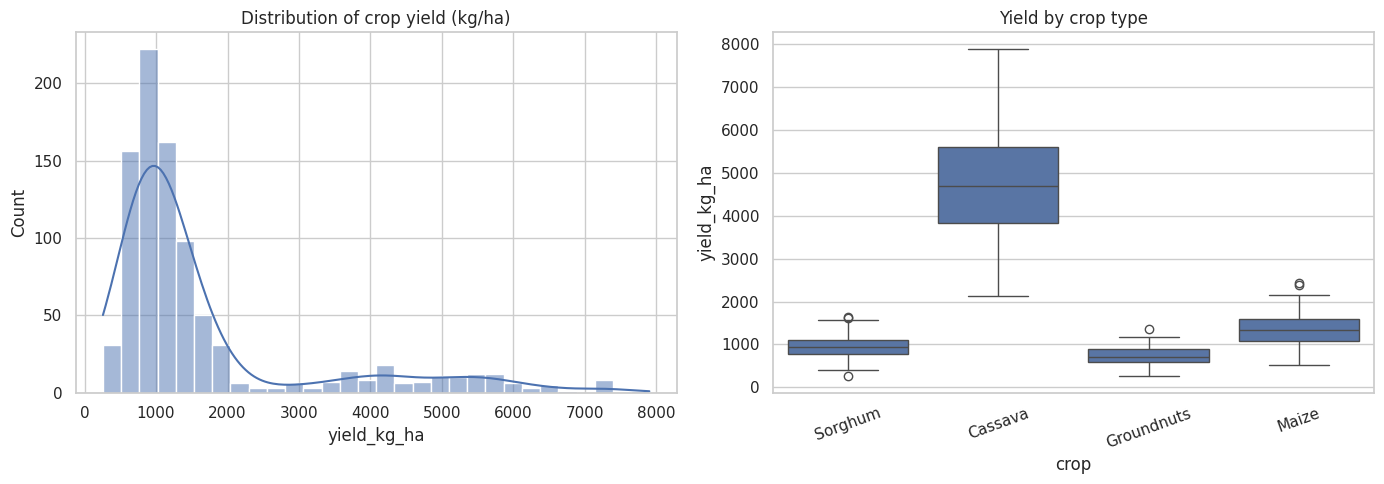

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["yield_kg_ha"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of crop yield (kg/ha)")

sns.boxplot(data=df, x="crop", y="yield_kg_ha", ax=axes[1])
axes[1].set_title("Yield by crop type")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


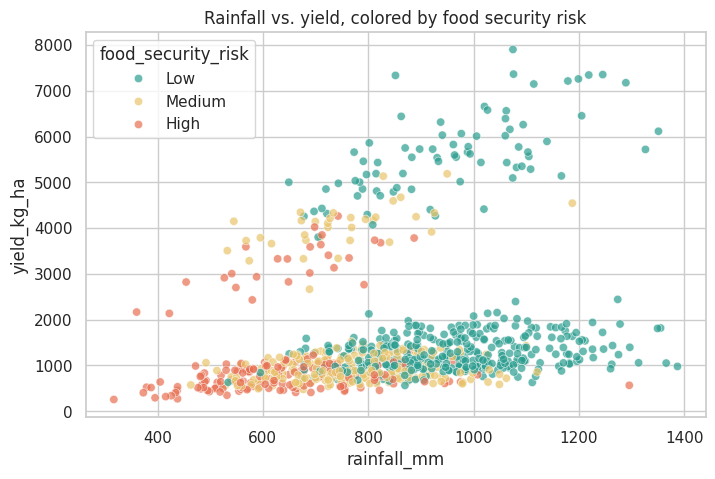

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x="rainfall_mm", y="yield_kg_ha",
    hue="food_security_risk", hue_order=["Low", "Medium", "High"],
    palette={"Low": "#2a9d8f", "Medium": "#e9c46a", "High": "#e76f51"},
    alpha=0.7
)
plt.title("Rainfall vs. yield, colored by food security risk")
plt.show()


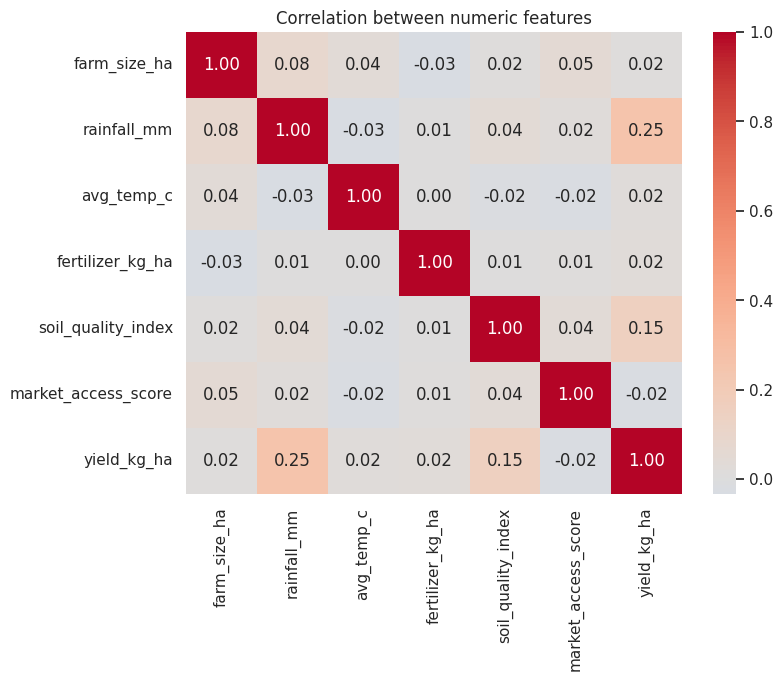

In [ ]:
numeric_cols = ["farm_size_ha", "rainfall_mm", "avg_temp_c", "fertilizer_kg_ha",
                 "soil_quality_index", "market_access_score", "yield_kg_ha"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between numeric features")
plt.show()


**Discussion (2 min):** Look at the plots above.
- Which feature seems to matter most for yield?
- Does the rainfall/yield relationship match what you'd expect for South Sudan?
- What happens to food security risk when rainfall is low?


## Part 4 — Cleaning & preparing the data

Real-world data is never perfectly ready for a model. We need to:

1. **Handle missing values** — models can't handle `NaN`. We'll fill numeric gaps with the **median** of that column (a simple, robust choice for a workshop).
2. **Encode categorical columns** — models only understand numbers, so `region` and `crop` (text categories) need to become numeric columns. We'll use **one-hot encoding** (`pd.get_dummies`), which creates a 0/1 column per category.
3. **Encode our classification target** — `food_security_risk` is currently text (`Low`/`Medium`/`High`); we'll map it to numbers (0/1/2) that preserve the natural order.
4. **Scale numeric features** — some models (like Logistic Regression) perform better when numeric features are on a similar scale.


In [ ]:
df_clean = df.copy()

# 1) Fill missing numeric values with the column median
numeric_features = ["farm_size_ha", "rainfall_mm", "avg_temp_c", "fertilizer_kg_ha",
                     "soil_quality_index", "market_access_score"]

imputer = SimpleImputer(strategy="median")
df_clean[numeric_features] = imputer.fit_transform(df_clean[numeric_features])

print("Missing values remaining:", df_clean[numeric_features].isnull().sum().sum())




Missing values remaining: 0


In [ ]:
# How many missing values does each column have?
df_clean.isnull().sum().sort_values(ascending=False)

,0
region,0
crop,0
farm_size_ha,0
rainfall_mm,0
avg_temp_c,0
fertilizer_kg_ha,0
soil_quality_index,0
market_access_score,0
yield_kg_ha,0
food_security_risk,0


In [ ]:
# 2) One-hot encode the categorical input columns
df_encoded = pd.get_dummies(df_clean, columns=["region", "crop"], drop_first=True)

# 3) Encode the classification target with a meaningful order: Low < Medium < High
risk_order = {"Low": 0, "Medium": 1, "High": 2}
df_encoded["food_security_risk_encoded"] = df_encoded["food_security_risk"].map(risk_order)

df_encoded.head()


,farm_size_ha,rainfall_mm,avg_temp_c,fertilizer_kg_ha,soil_quality_index,market_access_score,yield_kg_ha,food_security_risk,region_Eastern Equatoria,region_Jonglei,...,region_Northern Bahr el Ghazal,region_Unity,region_Upper Nile,region_Warrap,region_Western Bahr el Ghazal,region_Western Equatoria,crop_Groundnuts,crop_Maize,crop_Sorghum,food_security_risk_encoded
0,2.55,1182.10,28.6,27.8,3.6,4.3,1051.2,Low,False,False,...,False,False,False,False,False,False,False,False,True,0
1,2.00,809.30,29.2,9.1,6.4,8.0,4171.3,Medium,False,False,...,False,False,False,False,False,False,False,False,False,1
2,4.47,839.30,31.2,3.2,4.4,4.2,630.4,Medium,False,False,...,False,False,False,True,False,False,True,False,False,1
3,1.96,519.50,28.8,8.3,2.5,3.6,551.3,High,False,False,...,False,True,False,False,False,False,False,False,True,2
4,3.18,826.55,30.0,10.1,5.4,9.1,762.0,Medium,False,False,...,False,True,False,False,False,False,False,False,True,1


## Part 5 — Splitting the data

We never evaluate a model on the same data it was trained on — that would be like grading a student using the exact questions they memorized the answers to. Instead, we hold out a **test set** the model never sees during training, and use it only at evaluation time.

A common split is **80% train / 20% test**. `scikit-learn`'s `train_test_split` does this (with shuffling) in one line.


In [ ]:
feature_cols = [c for c in df_encoded.columns
                 if c not in ["yield_kg_ha", "food_security_risk", "food_security_risk_encoded"]]

X = df_encoded[feature_cols]
y_reg = df_encoded["yield_kg_ha"]                 # regression target
y_clf = df_encoded["food_security_risk_encoded"]   # classification target

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=RANDOM_STATE
)

# Scale numeric features (fit on train only, to avoid leaking test information)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print(f"Training rows: {len(X_train)}   Test rows: {len(X_test)}")


Training rows: 720   Test rows: 180


## Part 6 — Regression: predicting crop yield

We'll train two regression models and compare them:

- **Linear Regression** — a simple, interpretable baseline
- **Random Forest Regressor** — an ensemble of decision trees, usually more accurate on messy real-world data

### Evaluation metrics for regression
- **MAE (Mean Absolute Error):** average size of the prediction error, in the same units as the target (kg/ha) — easy to interpret.
- **RMSE (Root Mean Squared Error):** similar, but penalizes large errors more.
- **R² (R-squared):** how much of the variation in yield the model explains (1.0 = perfect, 0 = no better than guessing the average).


In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_reg_train)
lin_reg_preds = lin_reg.predict(X_test_scaled)

rf_reg = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
rf_reg.fit(X_train, y_reg_train)  # tree models don't need scaled features
rf_reg_preds = rf_reg.predict(X_test)

def report_regression(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f"{name:22s}  MAE={mae:8.1f} kg/ha   RMSE={rmse:8.1f} kg/ha   R²={r2:.3f}")

report_regression("Linear Regression", y_reg_test, lin_reg_preds)
report_regression("Random Forest", y_reg_test, rf_reg_preds)


Linear Regression       MAE=   269.6 kg/ha   RMSE=   395.2 kg/ha   R²=0.937
Random Forest           MAE=   205.1 kg/ha   RMSE=   315.9 kg/ha   R²=0.960


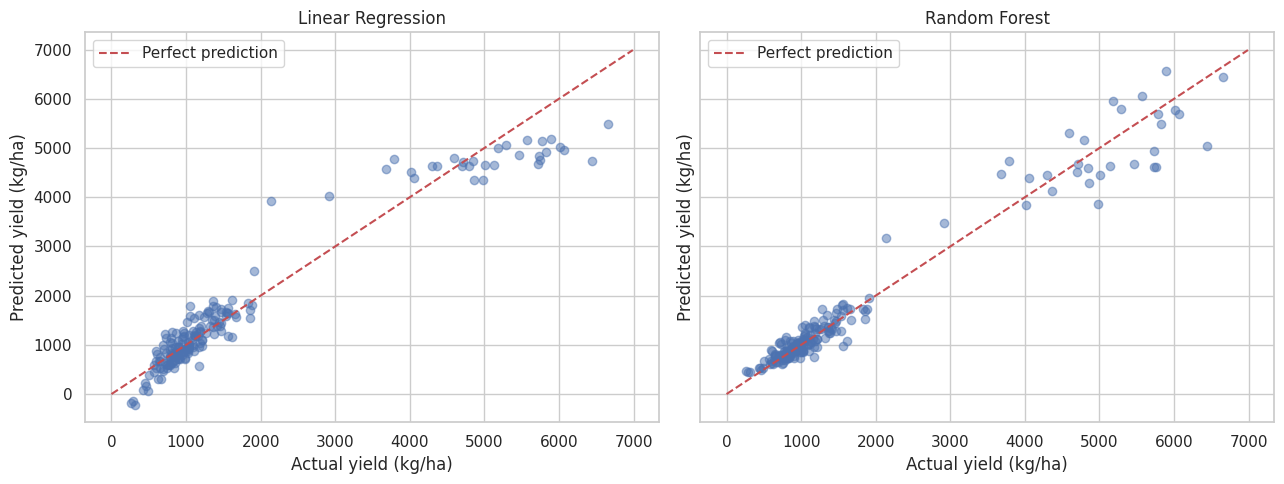

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

for ax, preds, title in zip(axes, [lin_reg_preds, rf_reg_preds], ["Linear Regression", "Random Forest"]):
    ax.scatter(y_reg_test, preds, alpha=0.5)
    lims = [0, max(y_reg_test.max(), preds.max()) * 1.05]
    ax.plot(lims, lims, "r--", label="Perfect prediction")
    ax.set_xlabel("Actual yield (kg/ha)")
    ax.set_ylabel("Predicted yield (kg/ha)")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()


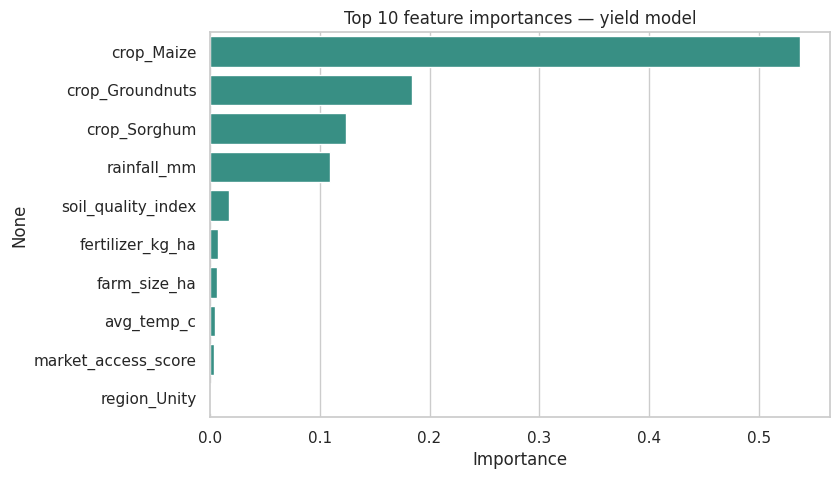

In [ ]:
# Which features does the Random Forest rely on most?
importances = pd.Series(rf_reg.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, color="#2a9d8f")
plt.title("Top 10 feature importances — yield model")
plt.xlabel("Importance")
plt.show()


## Part 7 — Classification: predicting food security risk

Now let's predict a **category** instead of a number: is a household's food security risk this season **Low**, **Medium**, or **High**?

We'll again compare two models:

- **Logistic Regression** — a simple, fast, interpretable baseline for classification
- **Random Forest Classifier** — usually stronger on non-linear relationships

### Evaluation metrics for classification
- **Accuracy:** fraction of predictions that were exactly correct.
- **Confusion matrix:** shows *which* categories get confused with each other.
- **Classification report:** precision/recall/F1 per class — important because accuracy alone can be misleading if classes are imbalanced.


In [ ]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_clf_train)
log_reg_preds = log_reg.predict(X_test_scaled)

rf_clf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_clf.fit(X_train, y_clf_train)
rf_clf_preds = rf_clf.predict(X_test)

print(f"Logistic Regression accuracy: {accuracy_score(y_clf_test, log_reg_preds):.3f}")
print(f"Random Forest accuracy:       {accuracy_score(y_clf_test, rf_clf_preds):.3f}")


Logistic Regression accuracy: 0.689
Random Forest accuracy:       0.689


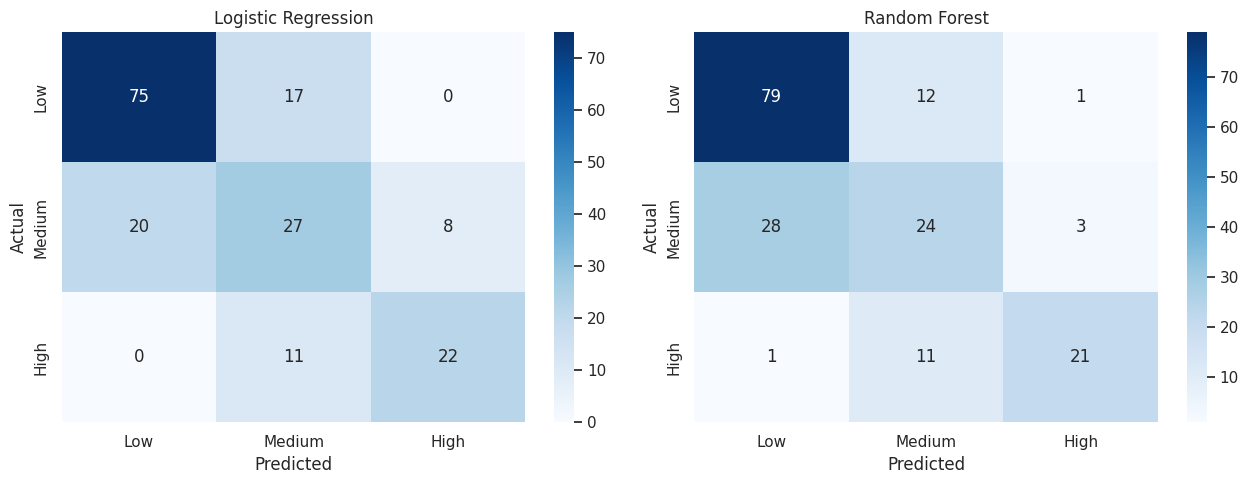

In [ ]:
labels = ["Low", "Medium", "High"]
label_order = [0, 1, 2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, title in zip(axes, [log_reg_preds, rf_clf_preds], ["Logistic Regression", "Random Forest"]):
    cm = confusion_matrix(y_clf_test, preds, labels=label_order)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

plt.tight_layout()
plt.show()


In [ ]:
print("Random Forest classification report:\n")
print(classification_report(y_clf_test, rf_clf_preds, target_names=labels, zero_division=0))


Random Forest classification report:

              precision    recall  f1-score   support

         Low       0.73      0.86      0.79        92
      Medium       0.51      0.44      0.47        55
        High       0.84      0.64      0.72        33

    accuracy                           0.69       180
   macro avg       0.69      0.64      0.66       180
weighted avg       0.68      0.69      0.68       180



In [ ]:
# ---- Input values----
region = "Jonglei"
crop = "Sorghum"
farm_size_ha = 1.5
rainfall_mm = 550
avg_temp_c = 30
fertilizer_kg_ha = 10
soil_quality_index = 4.5
market_access_score = 3.0
# -----------------------------------

row = pd.DataFrame([np.zeros(len(X_train.columns))], columns=X_train.columns)
row["farm_size_ha"] = farm_size_ha
row["rainfall_mm"] = rainfall_mm
row["avg_temp_c"] = avg_temp_c
row["fertilizer_kg_ha"] = fertilizer_kg_ha
row["soil_quality_index"] = soil_quality_index
row["market_access_score"] = market_access_score
for col in [f"region_{region}", f"crop_{crop}"]:
    if col in row.columns:
        row[col] = 1k

labels = {0: "Low", 1: "Medium", 2: "High"}
print("Food security risk:", labels[int(rf_clf.predict(row)[0])])

Food security risk: High


## Part 8 — 🧪 Hands-on challenge: try it yourself!

You've now seen the full ML workflow end to end. In this section, **you** make the changes. Work through as many exercises as you can — they build on each other but are otherwise independent, so skip around if you get stuck on one.

Facilitators are walking the room — flag them down any time!


### Exercise 1 (worked example) — Try a Decision Tree

Below is a **solved** example to show you the pattern: train a `DecisionTreeRegressor` on the same training data, and compare it to the two models above.


In [ ]:
# SOLVED EXAMPLE — run this cell, then use the same pattern for the exercises below
dt_reg = DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE)
dt_reg.fit(X_train, y_reg_train)
dt_reg_preds = dt_reg.predict(X_test)

report_regression("Decision Tree", y_reg_test, dt_reg_preds)
report_regression("Random Forest", y_reg_test, rf_reg_preds)  # for comparison


Decision Tree           MAE=   234.9 kg/ha   RMSE=   388.4 kg/ha   R²=0.939
Random Forest           MAE=   205.1 kg/ha   RMSE=   315.9 kg/ha   R²=0.960


### Exercise 2 — Engineer a new feature

Real ML work is often less about the model and more about the **features** you feed it. Create a new column, e.g. `fertilizer_per_ha = fertilizer_kg_ha / farm_size_ha`, add it to your feature set, retrain a `RandomForestRegressor`, and see whether MAE improves.

Fill in the `# TODO` lines below.


In [ ]:
# 🧪 TODO: engineer a new feature and see if it helps the yield model
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

# TODO: create the new feature on both X_train_fe and X_test_fe
# X_train_fe["fertilizer_per_ha"] = ...
# X_test_fe["fertilizer_per_ha"] = ...

# TODO: retrain a RandomForestRegressor on the new feature set
# rf_reg_fe = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
# rf_reg_fe.fit(X_train_fe, y_reg_train)
# rf_reg_fe_preds = rf_reg_fe.predict(X_test_fe)

# TODO: compare to the original Random Forest with report_regression(...)


### Exercise 3 — Does the train/test split matter?

Try changing `test_size` (e.g. to `0.3`) and/or `random_state` (e.g. to `7`) in a new `train_test_split` call, retrain the Random Forest classifier, and see how much accuracy moves around. This is a good way to build intuition for why we shouldn't trust a single train/test split too much.


In [ ]:
# 🧪 TODO: try a different split and see how accuracy changes
# X_train2, X_test2, y_clf_train2, y_clf_test2 = train_test_split(
#     X, y_clf, test_size=0.3, random_state=7
# )
# rf_clf2 = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
# rf_clf2.fit(X_train2, y_clf_train2)
# print("Accuracy with new split:", accuracy_score(y_clf_test2, rf_clf2.predict(X_test2)))


### Exercise 4 (stretch) — Predict for a brand-new farm

Write a small function that takes in raw values for one farm (region, crop, rainfall, etc.), builds a single-row DataFrame that matches your training columns, and returns both the predicted yield and predicted food security risk. This is exactly the kind of function you'll want at the hackathon to turn a trained model into something useful.

*Hint:* the trickiest part is making sure your new row has the **same one-hot-encoded columns**, in the **same order**, as `X_train`. Start from a DataFrame of all zeros with `X_train.columns`, then fill in the values you know.


In [ ]:
# 🧪 STRETCH TODO: build a predict_for_new_farm(...) function
def predict_for_new_farm(region, crop, farm_size_ha, rainfall_mm, avg_temp_c,
                          fertilizer_kg_ha, soil_quality_index, market_access_score):
    # TODO: start with a single row of zeros using X_train.columns
    # row = pd.DataFrame([np.zeros(len(X_train.columns))], columns=X_train.columns)

    # TODO: fill in the numeric columns directly, e.g.
    # row["farm_size_ha"] = farm_size_ha
    # ... etc for the other numeric columns ...

    # TODO: set the matching one-hot column to 1, e.g. row[f"region_{region}"] = 1
    #       (be careful: the first region/crop alphabetically was dropped by drop_first=True!)

    # TODO: predict yield with rf_reg.predict(row) and risk with rf_clf.predict(row)
    # return predicted_yield, predicted_risk_label
    pass

# Example call once you've implemented it above:
# predict_for_new_farm("Jonglei", "Sorghum", 1.5, 550, 30, 10, 4.5, 3.0)


## Part 9 — Wrap-up & next steps

### What you practiced today
- The end-to-end ML workflow: define → collect → explore → clean → split → train → evaluate → iterate
- Handling missing values and encoding categorical data
- Training and comparing **regression** models (Linear Regression, Random Forest, Decision Tree)
- Training and comparing **classification** models (Logistic Regression, Random Forest)
- Reading evaluation metrics: MAE, RMSE, R², accuracy, confusion matrices, precision/recall

### Where this goes next: IndabaX South Sudan 2026
This workshop was designed to build the exact muscles you'll need for the **IndabaX South Sudan 2026 hackathon**, where teams will tackle a real **agriculture / food security forecasting** problem using data grounded in South Sudan. The pipeline you just built — clean data, engineer features, train a few models, evaluate honestly, iterate — is the same pipeline you'll use there, just with real data and a real problem statement.

### Keep learning
- [scikit-learn documentation](https://scikit-learn.org/stable/) — the library we used throughout
- [Kaggle Learn](https://www.kaggle.com/learn) — free short courses on ML, pandas, and more
- Re-run this notebook on your own and try swapping in a real dataset (e.g. from South Sudan's National Bureau of Statistics) using the same workflow

### Thank you!
Thank you for taking part in the Scenius Hub / IndabaX South Sudan 2026 hands-on workshop. We look forward to seeing what you build at the hackathon!
